In [1]:
%pip install matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


group_labels = ["VE-Non-SNV", "VE-Coding"]
series_labels = ["Paper Qwen3-1B", "Paper Qwen3-4B", "Ours qwen3:1.7b", "Ours qwen3:4b"]
series_colors = ["#D9D9D9", "#7A7A7A", "#FBC9D9", "#D6537A"]

accuracy = {
    "Paper Qwen3-1B":  [70.67, 46.55],
    "Paper Qwen3-4B":  [61.86, 48.99],
    "Ours qwen3:1.7b": [58.42, 69.50],
    "Ours qwen3:4b":   [53.50, 77.50],
}

pathogenic_f1 = {
    "Paper Qwen3-1B":  [76.21, 34.82],
    "Paper Qwen3-4B":  [67.60, 39.58],
    "Ours qwen3:1.7b": [72.19, 76.06],
    "Ours qwen3:4b":   [55.92, 75.14],
}

# ---- Figure 3 data: confusion matrices, rows/cols = [Pathogenic, Benign] ----
confusion_matrices = {
    ("qwen3:1.7b", "VE-Non-SNV"): {"cm": np.array([[465, 58], [304, 46]]), "n": 873, "max_tokens": 1500},
    ("qwen3:4b",   "VE-Non-SNV"): {"cm": np.array([[59, 61], [32, 48]]),  "n": 200, "max_tokens": 4000},
    ("qwen3:1.7b", "VE-Coding"):  {"cm": np.array([[81, 29], [32, 58]]),  "n": 200, "max_tokens": 1500},
    ("qwen3:4b",   "VE-Coding"):  {"cm": np.array([[68, 42], [3, 87]]),   "n": 200, "max_tokens": 4000},
}

# quick sanity check: each matrix's accuracy should match Tables 3/4
for (model, ds), d in confusion_matrices.items():
    cm = d["cm"]
    acc = (cm[0,0] + cm[1,1]) / cm.sum() * 100
    print(f"{model:10s} {ds:12s} n={cm.sum():4d}  accuracy={acc:.2f}%")

qwen3:1.7b VE-Non-SNV   n= 873  accuracy=58.53%
qwen3:4b   VE-Non-SNV   n= 200  accuracy=53.50%
qwen3:1.7b VE-Coding    n= 200  accuracy=69.50%
qwen3:4b   VE-Coding    n= 200  accuracy=77.50%


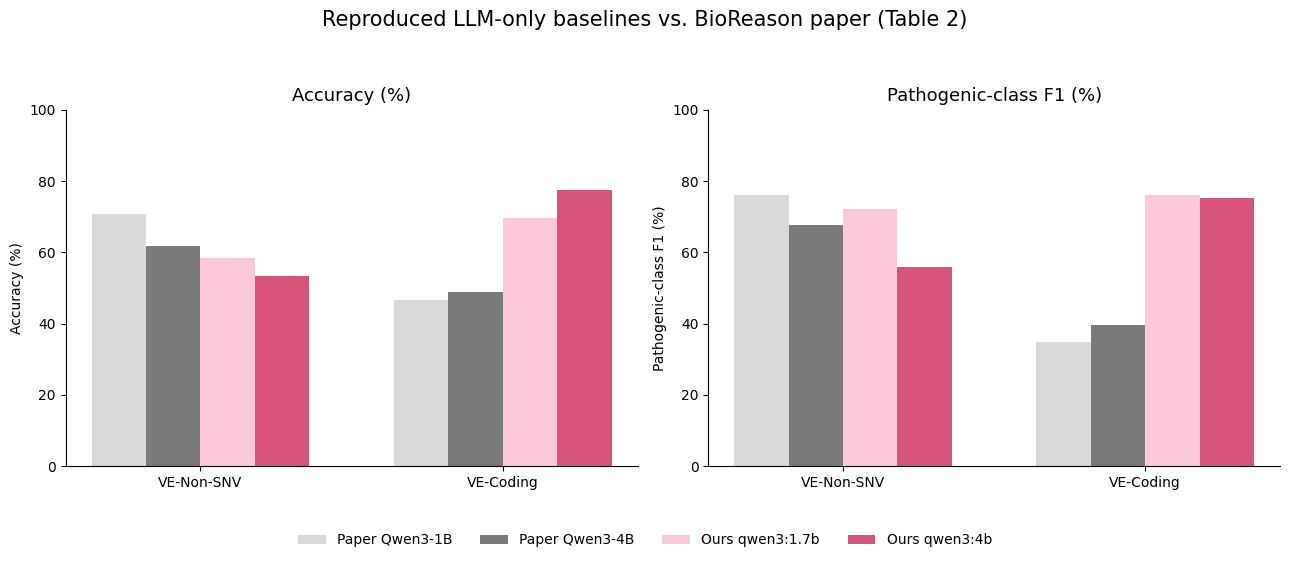

In [3]:
def plot_grouped_bars(ax, metric_dict, title, ylabel):
    n_series = len(series_labels)
    width = 0.18
    x = np.arange(len(group_labels))

    for i, label in enumerate(series_labels):
        offset = (i - (n_series - 1) / 2) * width
        ax.bar(x + offset, metric_dict[label], width=width,
               color=series_colors[i], label=label)

    ax.set_title(title, fontsize=13)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 100)
    ax.set_xticks(x)
    ax.set_xticklabels(group_labels)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

plot_grouped_bars(axes[0], accuracy, "Accuracy (%)", "Accuracy (%)")
plot_grouped_bars(axes[1], pathogenic_f1, "Pathogenic-class F1 (%)", "Pathogenic-class F1 (%)")

fig.suptitle("Reproduced LLM-only baselines vs. BioReason paper (Table 2)", fontsize=15)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.08, 1, 0.93])

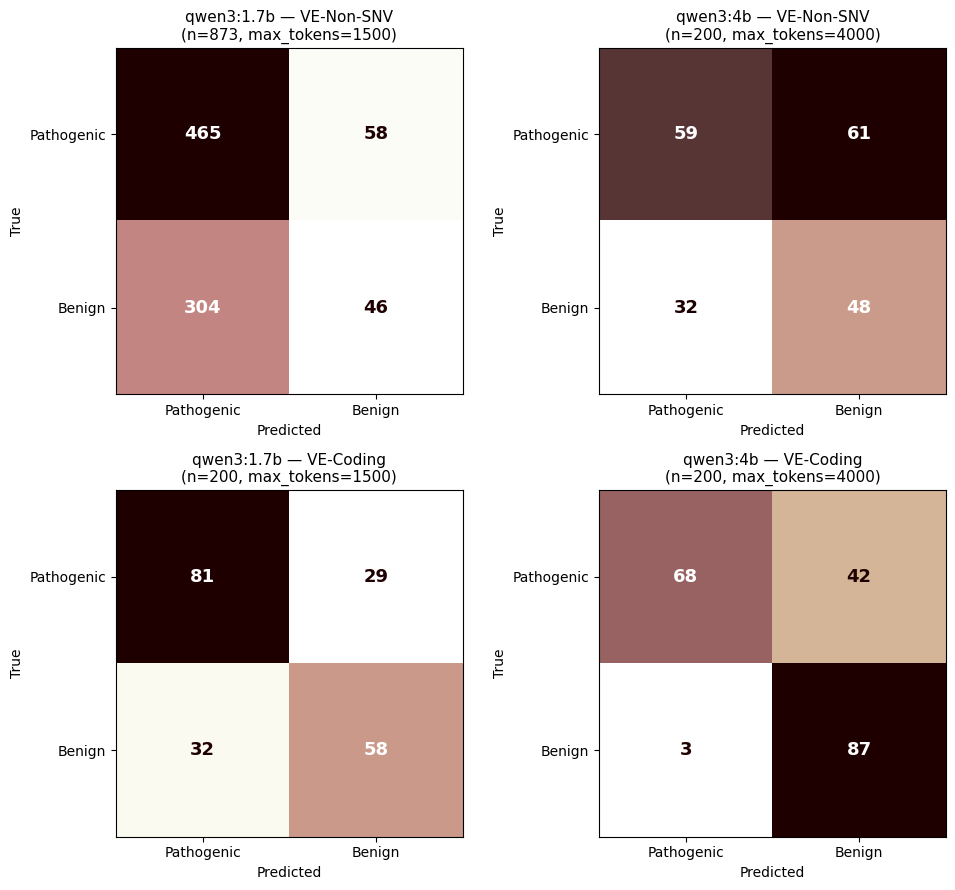

In [9]:
labels = ["Pathogenic", "Benign"]

cm_order = [
    ("qwen3:1.7b", "VE-Non-SNV"),
    ("qwen3:4b",   "VE-Non-SNV"),
    ("qwen3:1.7b", "VE-Coding"),
    ("qwen3:4b",   "VE-Coding"),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 9))

for ax, key in zip(axes.flat, cm_order):
    model, dataset = key
    info = confusion_matrices[key]

    disp = ConfusionMatrixDisplay(confusion_matrix=info["cm"], display_labels=labels)
    disp.plot(ax=ax, cmap="pink_r", colorbar=False, values_format="d")

    for text in disp.text_.ravel():
        text.set_fontweight("bold")
        text.set_fontsize(13)

    ax.set_title(f"{model} — {dataset}\n(n={info['n']}, max_tokens={info['max_tokens']})", fontsize=11)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.savefig("figure3_confusion_matrices.png", dpi=200, bbox_inches="tight")
plt.show()